<a href="https://colab.research.google.com/github/anirbanghoshsbi/.github.io/blob/master/work/indicator/temp/GET_FII_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
!pip install pyotp --q
!pip install smartapi-python==1.4.1 --q
!pip install logzero --q

In [66]:
import matplotlib.pyplot as plt
from matplotlib.dates import MonthLocator,YearLocator

In [67]:
# package import statement
from SmartApi import SmartConnect #or from SmartApi.smartConnect import SmartConnect
import pyotp
from logzero import logger
import time
import os
import urllib
import json
import pandas as pd
import datetime as dt

api_key = 'xOHnB7MG'
username = 'M55123447'
pwd = '1471'
smartApi = SmartConnect(api_key)
try:
    token = "GJZACUQI2TTAIBHBA34XNFJURQ"
    totp = pyotp.TOTP(token).now()
except Exception as e:
    logger.error("Invalid Token: The provided token is not valid.")
    raise e

correlation_id = "abcde"
data = smartApi.generateSession(username, pwd, totp)

if data['status'] == False:
    logger.error(data)

else:
    # login api call
    # logger.info(f"You Credentials: {data}")
    authToken = data['data']['jwtToken']
    refreshToken = data['data']['refreshToken']
    # fetch the feedtoken
    feedToken = smartApi.getfeedToken()
    # fetch User Profile
    res = smartApi.getProfile(refreshToken)
    smartApi.generateToken(refreshToken)
    res=res['data']['exchanges']
#Download Nifty50 Index Data
params = {
           "exchange": "NSE",
           "symboltoken": '99926000',
           "interval": "ONE_DAY",
           "fromdate": (dt.datetime(2020, 9, 21).strftime('%Y-%m-%d %H:%M')),
           "todate": (dt.datetime.today().strftime('%Y-%m-%d %H:%M'))
         }
nifty_data = smartApi.getCandleData(params)
nifty_data_format= pd.DataFrame(nifty_data["data"],
                               columns = ["Date","Open","High","Low","Close","Volume"])
nifty_data_format.set_index("Date",inplace=True)
nifty_data_format.index = pd.to_datetime(nifty_data_format.index)
nifty_data_format.index = nifty_data_format.index.tz_localize(None)

In [68]:
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.simplefilter(action='ignore', category=Warning)
import yfinance as yf

In [69]:
import numpy as np
import pandas as pd
#from pykalman import KalmanFilter
#import pandas_ta as ta

In [70]:
nif=nifty_data_format

In [71]:
nif.tail(2)

,Open,High,Low,Close,Volume
Date,,,,,
2026-03-24,22878.45,23057.30,22624.2,22912.40,0
2026-03-25,23064.40,23465.35,23063.2,23306.45,0


In [72]:
nif.head(2)
nif.reset_index(inplace=True)

In [73]:
fii=pd.read_csv('https://raw.githubusercontent.com/anirbanghoshsbi/.github.io/refs/heads/master/work/ml/fii_dii_sorted.csv')

In [74]:
# Convert both Date columns to datetime
nif["Date"] = pd.to_datetime(nif["Date"])
fii["Date"] = pd.to_datetime(fii["Date"])

# Remove timestamp part from df2
nif["Date"] = nif["Date"].dt.date
fii["Date"] = fii["Date"].dt.date

In [75]:
fii_fig = pd.merge(fii, nif, on="Date", how="inner")

# Change Here

In [76]:
fii_fig['Cash']=fii_fig.FIICash+fii_fig.DIIcash

In [77]:
fii_fig['Cashfut']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signalfutcash']=fii_fig['Cashfut'].ewm(span=22,adjust=False).mean()
fii_fig['signal10futcash']=fii_fig['Cashfut'].ewm(span=10,adjust=False).mean()

# Plot FII minus DII

In [78]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=50, adjust=False).mean()-fii_fig['Cash'].ewm(span=100, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=25,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=10,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [79]:
fii_fig['macdy']=fii_fig['Cash'].ewm(span=100, adjust=False).mean()-fii_fig['Cash'].ewm(span=250, adjust=False).mean()
fii_fig['signaly']=fii_fig['macdy'].ewm(span=45,adjust=False).mean()
fii_fig['signal10y']=fii_fig['macdy'].ewm(span=20,adjust=False).mean()
fii_fig['histy']=fii_fig['macdy']-fii_fig['signaly']

In [80]:
fii_fig['macd']=fii_fig['DIIcash'].ewm(span=50, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=35,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']

In [81]:
fii_fig['macdx']=fii_fig['FIICash'].ewm(span=50, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signalx']=fii_fig['macdx'].ewm(span=35,adjust=False).mean()
fii_fig['signal10x']=fii_fig['macdx'].ewm(span=10,adjust=False).mean()
fii_fig['histx']=fii_fig['macdx']-fii_fig['signalx']

# Plot FII , DII , Difference comparison

In [82]:
fii_fig['macd']=fii_fig['FIICash'].ewm(span=20, adjust=False).mean()-fii_fig['FIICash'].ewm(span=200, adjust=False).mean()
fii_fig['signal']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['signal10']=fii_fig['macd'].ewm(span=10,adjust=False).mean()
fii_fig['hist']=fii_fig['macd']-fii_fig['signal']


In [83]:
fii_fig['macd_dom']=fii_fig['DIIcash'].ewm(span=20, adjust=False).mean()-fii_fig['DIIcash'].ewm(span=200, adjust=False).mean()
fii_fig['signal_dom']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['signal_dom_10']=fii_fig['DIIcash'].ewm(span=10,adjust=False).mean()
fii_fig['hist_dom']=fii_fig['macd_dom']-fii_fig['signal_dom']

In [84]:
nif.reset_index(inplace=True)
fii_fig.reset_index(inplace=True)
# Convert the 'Date' column in both DataFrames to the same data type
nif['Date'] = pd.to_datetime(nif['Date'])
fii_fig['Date'] = pd.to_datetime(fii_fig['Date'])

# Merge nif and fii_fig DataFrames on the 'Date' column
merged_df = pd.merge(nif, fii_fig, on='Date')


In [85]:
fii_fig['MA200']=fii_fig.Close.rolling(window=200).mean()
fii_fig['MA20']=fii_fig.Close.rolling(window=20).mean()
fii_fig['MA13']=fii_fig.Close.rolling(window=13).mean()
fii_fig['MA26']=fii_fig.Close.rolling(window=26).mean()
fii_fig['MA12']=fii_fig.Close.ewm(span=12,adjust=False).mean()
# --------------------------
# MACD
# --------------------------
fii_fig["macd_impulse"] = fii_fig["MA12"] - fii_fig["MA26"]

# MACD Signal
fii_fig["macd_signal"] = fii_fig["macd_impulse"].ewm(span=9, adjust=False).mean()

# MACD Histogram
fii_fig["macd_hist"] = fii_fig["macd_impulse"] - fii_fig["macd_signal"]

In [86]:
fii_fig["ema_slope"] = fii_fig["MA13"].diff()
fii_fig["macd_slope"] = fii_fig["macd_hist"].diff()

fii_fig["impulse"] = "blue"

fii_fig.loc[
    (fii_fig["ema_slope"] > 0) & (fii_fig["macd_slope"] > 0),
    "impulse"
] = "green"

fii_fig.loc[
    (fii_fig["ema_slope"] < 0) & (fii_fig["macd_slope"] < 0),
    "impulse"
] = "red"

In [87]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13',
       'MA26', 'MA12', 'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope',
       'macd_slope', 'impulse'],
      dtype='object')

# Plot Smart Money (FII)

In [88]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd'], mode='lines', name = 'macd'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=df.Date, y=df['signal'], mode='lines', name = 'signal'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date, y=df['signal10'], mode='lines', name = 'signal10'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="Smart Money And Nifty")

fig.show()

In [89]:
from plotly.subplots import make_subplots
df=fii_fig.reset_index()
#nif.reset_index(inplace=True)
fig = make_subplots(
    rows=2, cols=1,shared_xaxes=True,vertical_spacing=0.02,
    subplot_titles=("Smart Money DII","Nifty"))

fig.add_trace(go.Scatter(x=df.Date, y=df['macd_dom'], mode='lines', name = 'macd'),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df.Date,y=df['macd_dom'].rolling(window=10).mean(),mode='lines',name='moving-average 10'),
              row=1, col=1)

fig.add_trace(go.Scatter(x=nif.Date, y=nif['Close'], mode='lines', name = 'Close'),
              row=2, col=1)

fig.update_layout(title_text="DII Money And Nifty")

fig.show()

In [139]:
fii_fig['macd_z'] = (
    fii_fig['macd'] - fii_fig['macd'].rolling(60).mean()
) / fii_fig['macd'].rolling(60).std()

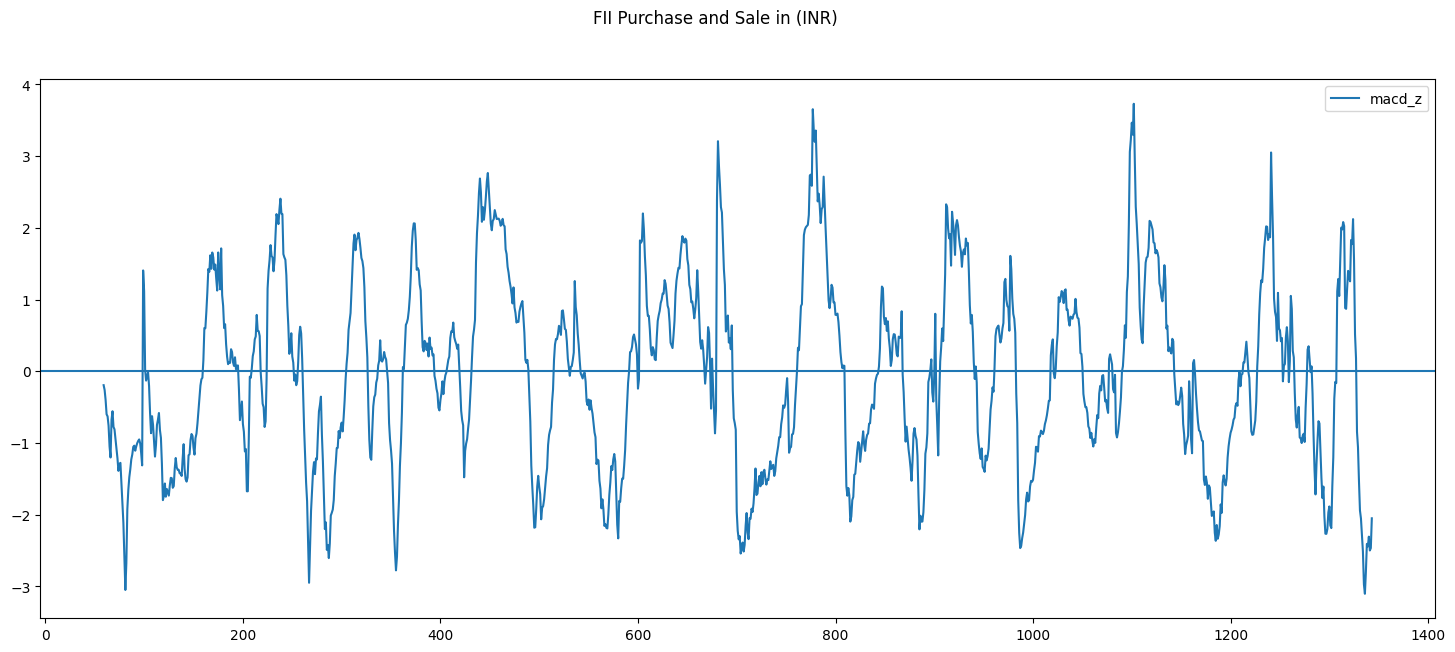

In [140]:
fii_fig['macd_z'].plot(figsize=(18,7))
plt.axhline(y=0)
#plt.axhline(y=1000,color='g')
#plt.axhline(y=2000,color='c')
#plt.axhline(y=-1000,color='r')
plt.suptitle('FII Purchase and Sale in (INR)')
plt.legend()
plt.show()

In [93]:
fii_fig['macd_regime'] = pd.cut(
    fii_fig['macd_z'],
    bins=[-np.inf,-1,-0.5,0,0.5,1,np.inf],
    labels=[
        'panic_selling',
        'strong_selling',
        'weak_selling',
        'weak_buying',
        'strong_buying',
        'euphoria'
    ]
)

In [141]:
fii_fig['ret_10d'] = (fii_fig['Close'].shift(-10) / fii_fig['Close'] - 1)*100

fii_fig.groupby('macd_regime')['ret_10d'].mean()

,ret_10d
macd_regime,
panic_selling,0.514020
strong_selling,0.388584
weak_selling,0.237587
weak_buying,0.149763
strong_buying,-0.515146
euphoria,0.661558


In [143]:
#fii_fig["Date"] = pd.to_datetime(fii_fig["Date"])

regime_slice = (
    fii_fig
    .set_index("Date")
    .loc["2025-04-03":"2025-04-27", ["macd_regime","ret_10d"]]
)

In [144]:
regime_slice

,macd_regime,ret_10d
Date,,
2025-04-03,euphoria,3.944714
2025-04-04,euphoria,6.219315
2025-04-07,strong_buying,9.408617
2025-04-08,weak_buying,6.671592
2025-04-09,weak_buying,8.613496
2025-04-11,weak_buying,6.603135
2025-04-15,strong_buying,4.310812
2025-04-16,euphoria,3.880583
2025-04-17,euphoria,2.555379


In [97]:
fii_fig['macd_regime'].iloc[-1]

'panic_selling'

In [98]:
fii_fig.groupby('macd_regime')['ret_10d'].median()*100

,ret_10d
macd_regime,
panic_selling,17.674298
strong_selling,33.131549
weak_selling,1.893307
weak_buying,33.328263
strong_buying,3.168713
euphoria,36.348706


In [99]:
fii_fig['trend_regime'] = np.where(
    fii_fig['Close'] > fii_fig['MA20'],
    'above_MA20',
    'below_MA20'
)

In [100]:
pd.pivot_table(
    fii_fig,
    values='ret_10d',
    index='macd_regime',
    columns='trend_regime',
    aggfunc='mean'
)

trend_regime,above_MA20,below_MA20
macd_regime,,
panic_selling,0.053549,0.227294
strong_selling,-0.048839,0.271627
weak_selling,0.000397,0.132143
weak_buying,0.207871,0.078860
strong_buying,-0.005560,-0.494111
euphoria,0.254942,0.195226


In [103]:
# MACD crossover conditions
fii_fig['macd_cross_up'] = (
    (fii_fig['macd'] > fii_fig['signal']) &
    (fii_fig['macd'].shift(1) <= fii_fig['signal'].shift(1))
)

fii_fig['macd_cross_down'] = (
    (fii_fig['macd'] < fii_fig['signal']) &
    (fii_fig['macd'].shift(1) >= fii_fig['signal'].shift(1))
)

In [104]:
fii_fig['ret_10d'] = fii_fig['Close'].shift(-20) / fii_fig['Close'] - 1

In [105]:

fii_fig['macd_event'] = np.select(
    [fii_fig['macd_cross_up'], fii_fig['macd_cross_down']],
    ['bullish_cross', 'bearish_cross'],
    default='no_cross'
)

In [106]:
result = fii_fig.groupby('macd_event')['ret_10d'].agg(
    count='count',
    mean='mean',
    median='median',
    win_rate=lambda x: (x > 0).mean()
)

print(result)

               count      mean    median  win_rate
macd_event                                        
bearish_cross     74  0.012602  0.009484  0.653333
bullish_cross     75  0.012629  0.012956  0.586667
no_cross        1175  0.011331  0.010856  0.618090


In [107]:
fii_fig['position'] = 0

fii_fig.loc[fii_fig['macd_cross_up'], 'position'] = 1
fii_fig.loc[fii_fig['macd_cross_down'], 'position'] = 0

fii_fig['position'] = fii_fig['position'].replace(to_replace=0, method='ffill')

In [108]:
fii_fig['ret'] = fii_fig['Close'].pct_change()
fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']
performance = {
    "mean_daily_return": fii_fig['strategy_ret'].mean(),
    "total_return": (1 + fii_fig['strategy_ret']).prod() - 1,
    "win_rate": (fii_fig['strategy_ret'] > 0).mean()
}

print(performance)

{'mean_daily_return': np.float64(0.0005564327706738184), 'total_return': np.float64(0.9984265674303838), 'win_rate': np.float64(0.5409226190476191)}


In [109]:
fii_fig['ma50'] = fii_fig['Close'].rolling(20).mean()
fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']

fii_fig['nifty_above_ma50'] = fii_fig['Close'] > fii_fig['ma50']

In [110]:
fii_fig['long_regime'] = (
    fii_fig['fii_macd_bullish'] &
    fii_fig['nifty_above_ma50']
)
fii_fig['position'] = fii_fig['long_regime'].astype(int)

In [111]:
fii_fig['ret'] = fii_fig['Close'].pct_change()

fii_fig['strategy_ret'] = fii_fig['position'].shift(1) * fii_fig['ret']

In [112]:
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & fii_fig['nifty_above_ma50'],
    'bullish_flow_uptrend',
    'other'
)

print(
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

                      count      mean    median  <lambda_0>
regime                                                     
bullish_flow_uptrend    516  0.002977  0.002204    0.670543
other                   827 -0.000937 -0.000629    0.461353


In [113]:
# 20 DMA
fii_fig['ma20'] = fii_fig['Close'].rolling(20).mean()

# distance from MA20
fii_fig['dist_ma20'] = (fii_fig['Close'] - fii_fig['ma20']) / fii_fig['ma20']

conditions = [
    fii_fig['dist_ma20'] > 0.02,
    fii_fig['dist_ma20'].between(0, 0.02),
    fii_fig['dist_ma20'] < 0
]

choices = [
    'strong_uptrend',
    'weak_uptrend',
    'bearish'
]

fii_fig['trend_regime'] = np.select(conditions, choices, default='neutral')

In [114]:

fii_fig['fii_macd_bullish'] = fii_fig['macd'] > fii_fig['signal']
fii_fig['regime'] = np.where(
    fii_fig['fii_macd_bullish'] & (fii_fig['dist_ma20'].between(0.03,1)),
    'flow_trend_bullish',
    'other'
)
fii_fig['ret'] = fii_fig['Close'].pct_change()

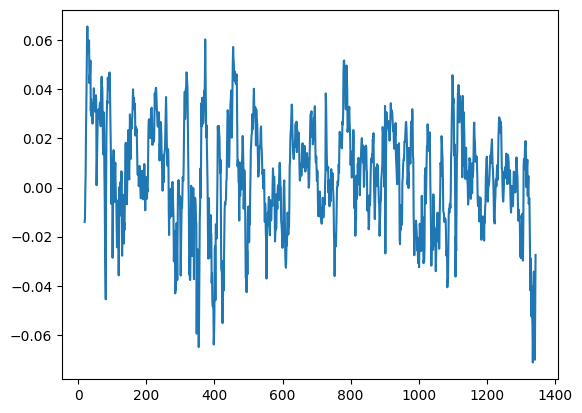

In [115]:
fii_fig['dist_ma20'].plot();

In [116]:
result = (
    fii_fig.groupby('regime')['ret']
    .agg(['count','mean','median',lambda x:(x>0).mean()])
)

print(result)

                    count      mean    median  <lambda_0>
regime                                                   
flow_trend_bullish    140  0.005212  0.005149    0.778571
other                1203  0.000026  0.000197    0.514120


In [117]:
df = fii_fig[fii_fig['macd'] > 0].copy()

In [118]:


bins = [0,0.02,0.04,0.06,0.08,.1]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [119]:
df['ret'] = df['Close'].pct_change()

In [120]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


              count      mean    median  win_rate
dist_bin                                         
(0.0, 0.02]     245  0.000064  0.000391  0.538776
(0.02, 0.04]    184  0.004128  0.003556  0.739130
(0.04, 0.06]     50  0.005533  0.005337  0.880000
(0.06, 0.08]      2  0.015509  0.015509  1.000000
(0.08, 0.1]       0       NaN       NaN       NaN


In [121]:
df = fii_fig[fii_fig['macd'] <= 0].copy()

In [122]:
bins = [-.1,-0.08,-0.06,-0.04,-0.02,0]

df['dist_bin'] = pd.cut(df['dist_ma20'], bins=bins)

In [123]:
result = (
    df.groupby('dist_bin')['ret']
    .agg(
        count='count',
        mean='mean',
        median='median',
        win_rate=lambda x:(x>0).mean()
    )
)

print(result)


                count      mean    median  win_rate
dist_bin                                           
(-0.1, -0.08]       0       NaN       NaN       NaN
(-0.08, -0.06]      6 -0.021113 -0.022869  0.000000
(-0.06, -0.04]     28 -0.008134 -0.007708  0.285714
(-0.04, -0.02]    111 -0.004931 -0.005045  0.288288
(-0.02, 0.0]      284 -0.000577 -0.001430  0.397887


In [124]:
fii_fig["exit_signal"] = fii_fig["Close"] < fii_fig["ma20"]

In [125]:
fii_fig["entry_signal"] = (
    (fii_fig["Close"] > fii_fig["ma20"]) &
    (fii_fig["macd"] > fii_fig['signal10']) &
    #(fii_fig["dist_ma20"] > 0) &
    (fii_fig["impulse"] == "green")
)

In [126]:
position = 0
entry_price = 0

trades = []

for i in range(len(fii_fig)):

    price = fii_fig["Close"].iloc[i]

    if position == 0:

        if fii_fig["entry_signal"].iloc[i]:
            position = 1
            entry_price = price
            entry_date = fii_fig.index[i]

    elif position == 1:

        if fii_fig["exit_signal"].iloc[i]:

            exit_price = price
            exit_date = fii_fig.index[i]

            ret = (exit_price / entry_price) - 1

            trades.append({
                "entry_date": entry_date,
                "exit_date": exit_date,
                "entry_price": entry_price,
                "exit_price": exit_price,
                "return": ret
            })

            position = 0

In [127]:
trades_df = pd.DataFrame(trades)

In [130]:
fii_fig.columns

Index(['index', 'Date', 'FIICash', 'DIIcash', 'Open', 'High', 'Low', 'Close',
       'Volume', 'Cash', 'Cashfut', 'signalfutcash', 'signal10futcash',
       'macdy', 'signaly', 'signal10y', 'histy', 'macd', 'signal', 'signal10',
       'hist', 'macdx', 'signalx', 'signal10x', 'histx', 'macd_dom',
       'signal_dom', 'signal_dom_10', 'hist_dom', 'MA200', 'MA20', 'MA13',
       'MA26', 'MA12', 'macd_impulse', 'macd_signal', 'macd_hist', 'ema_slope',
       'macd_slope', 'impulse', 'macd_z', 'macd_regime', 'ret_10d',
       'trend_regime', 'macd_cross_up', 'macd_cross_down', 'macd_event',
       'position', 'ret', 'strategy_ret', 'ma50', 'fii_macd_bullish',
       'nifty_above_ma50', 'long_regime', 'regime', 'ma20', 'dist_ma20',
       'exit_signal', 'entry_signal'],
      dtype='object')

In [136]:
print(fii_fig['macd_regime'].tail(1))
print('\n\n\n')
print(fii_fig['trend_regime'].tail(1))

1343    panic_selling
Name: macd_regime, dtype: category
Categories (6, object): ['panic_selling' < 'strong_selling' < 'weak_selling' < 'weak_buying' <
                         'strong_buying' < 'euphoria']




1343    bearish
Name: trend_regime, dtype: object


In [128]:
stats = {
    "trades": len(trades_df),
    "mean_return": trades_df["return"].mean(),
    "median_return": trades_df["return"].median(),
    "win_rate": (trades_df["return"] > 0).mean(),
    "max_gain": trades_df["return"].max(),
    "max_loss": trades_df["return"].min(),
}

print(stats)

{'trades': 41, 'mean_return': np.float64(0.010153655651152414), 'median_return': -0.005466956031966785, 'win_rate': np.float64(0.43902439024390244), 'max_gain': 0.12728899304098618, 'max_loss': -0.04715980955822652}
